## Credit Risk Model – Training & Evaluation
This code trains a Logistic Regression model to predict high-risk loans using 6 financial features. It cleans the data in Spark, splits it into train/test sets, and trains the model with class balancing to handle the imbalance between low and high risk loans. Finally, it evaluates the model using a classification report and ROC-AUC score, and prints each feature's coefficient to show which factors drive the risk prediction most.

In [99]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

spark = SparkSession.builder.getOrCreate()

feature_cols = ['debt_to_equity_ratio', 'loan_to_income_ratio',
                 'credit_score', 'interest_rate',
                'revenue_decline_flag', 'low_credit_score_flag']

# Step 1: Cast and clean in Spark
df_spark = spark.read.table("credit_risk_assessment.gold.loan_features")

for c in feature_cols:
    df_spark = df_spark.withColumn(c, F.col(c).cast("double"))
df_spark = df_spark.withColumn("high_dpd_flag", F.col("high_dpd_flag").cast("int"))

for c in feature_cols:
    df_spark = df_spark.filter(F.col(c).isNotNull())
    df_spark = df_spark.filter(~F.isnan(F.col(c)))
    df_spark = df_spark.filter(F.col(c) != float('inf'))
    df_spark = df_spark.filter(F.col(c) != float('-inf'))

df_spark = df_spark.select(feature_cols + ["high_dpd_flag"]).dropna()
print("Step 1 complete")

# Step 2: Collect as plain Python lists
rows = df_spark.collect()
X_list = [[float(row[c]) for c in feature_cols] for row in rows]
y_list = [int(row["high_dpd_flag"]) for row in rows]
print("Step 2 complete - Rows:", len(X_list))

# Step 3: Train/test split directly on Python lists
X_train, X_test, y_train, y_test = train_test_split(
    X_list, y_list, test_size=0.2, random_state=42
)
print("Step 3 complete - Train:", len(X_train), "Test:", len(X_test))

# Step 4: Train model
model = LogisticRegression(random_state=42,
    max_iter=1000,
    class_weight='balanced')
model.fit(X_train, y_train)
print("Step 4 complete - Model trained")

# Step 5: Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# Step 6: Feature importance - no pandas
coefficients = model.coef_[0].tolist()

pairs = list(zip(feature_cols, coefficients))
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

print("\nFeature Importance:")
print(f"{'Feature':<30} {'Coefficient'}")
print("-" * 45)
for feature, coef in pairs_sorted:
    print(f"{feature:<30} {float(coef):.6f}")

Step 1 complete


Step 2 complete - Rows: 10000
Step 3 complete - Train: 8000 Test: 2000


Step 4 complete - Model trained

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.58      0.73      1951
           1       0.03      0.49      0.05        49

    accuracy                           0.58      2000
   macro avg       0.50      0.54      0.39      2000
weighted avg       0.96      0.58      0.71      2000

ROC-AUC Score: 0.526

Feature Importance:
Feature                        Coefficient
---------------------------------------------
low_credit_score_flag          0.317558
debt_to_equity_ratio           0.026009
loan_to_income_ratio           0.011404
credit_score                   0.001159
interest_rate                  -0.037023
revenue_decline_flag           -0.070340


## Credit Risk Model – Performance Visualizations
This code generates 4 visual charts to evaluate the credit risk model. It plots the feature coefficients, a confusion matrix , how many loans were correctly/incorrectly classified, an ROC curve, overall model performance, and a risk score distribution how well the model separates low vs high risk loans.

In [95]:
!pip install matplotlib

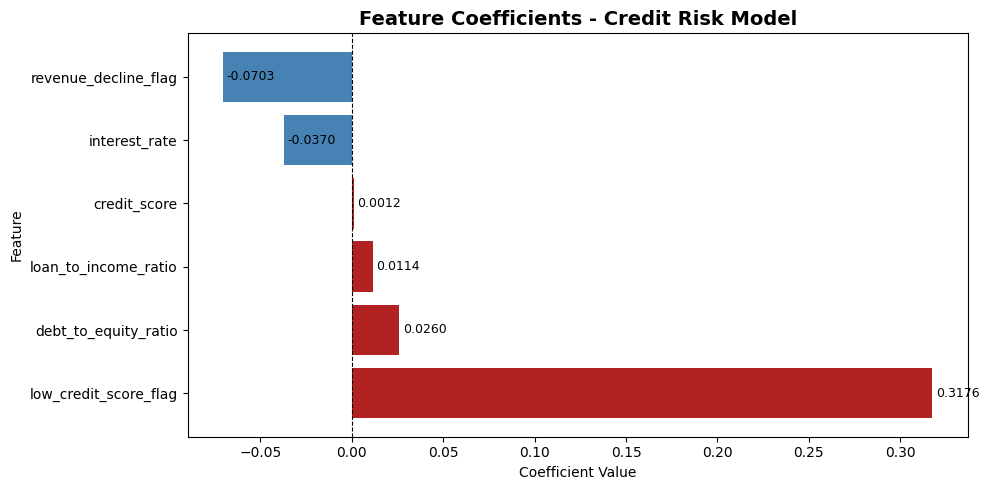

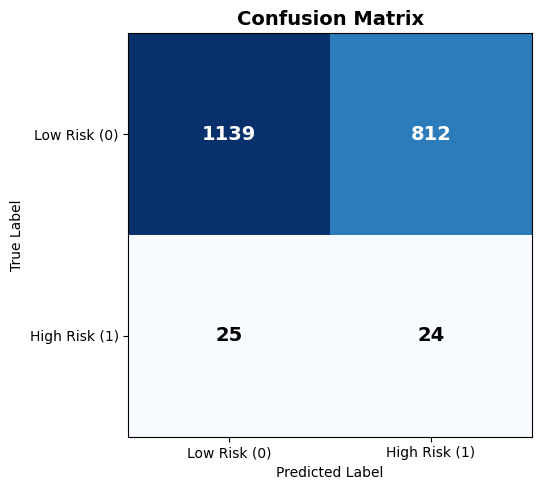

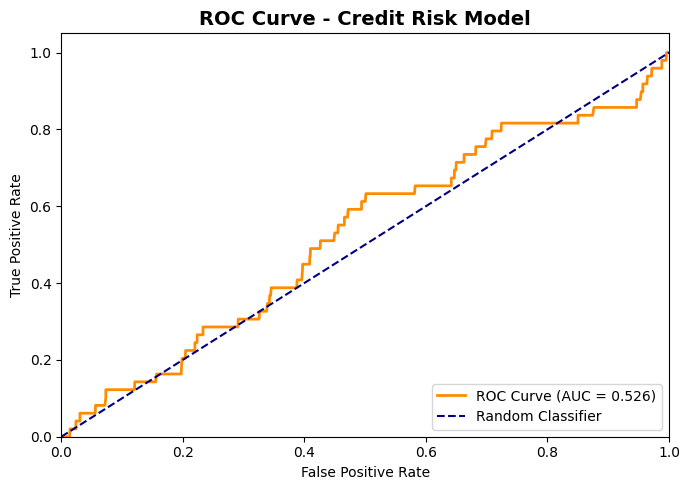

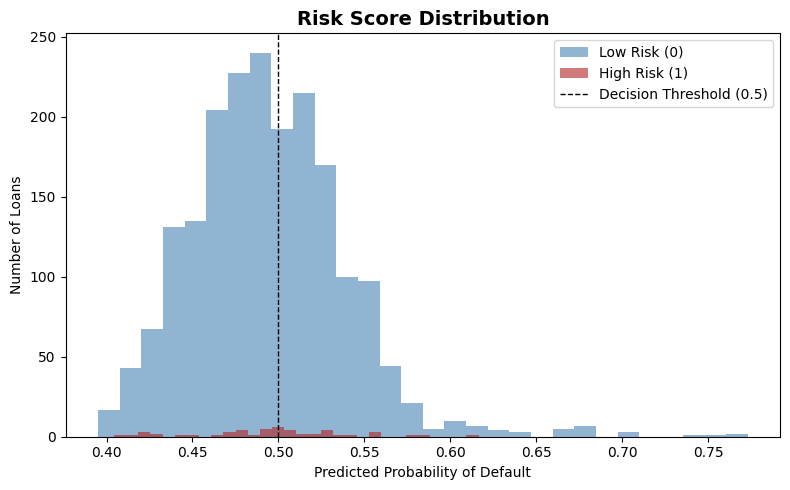

In [100]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ── Data prep ──────────────────────────────────────────────────────
coefficients = model.coef_[0].tolist()
pairs = sorted(zip(feature_cols, coefficients), key=lambda x: x[1], reverse=True)
features_sorted = [p[0] for p in pairs]
coefs_sorted    = [float(p[1]) for p in pairs]
colors          = ['firebrick' if c > 0 else 'steelblue' for c in coefs_sorted]

# ── Plot 1: Feature Coefficients ───────────────────────────────────
plt.figure(figsize=(10, 5))
bars = plt.barh(features_sorted, coefs_sorted, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients - Credit Risk Model', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
for bar, coef in zip(bars, coefs_sorted):
    plt.text(coef + 0.002, bar.get_y() + bar.get_height()/2,
             f'{coef:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── Plot 2: Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['Low Risk (0)', 'High Risk (1)'])
plt.yticks([0, 1], ['Low Risk (0)', 'High Risk (1)'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i][j]), ha='center', va='center',
                 color='white' if cm[i][j] > cm.max()/2 else 'black',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 3: ROC Curve ──────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = round(roc_auc_score(y_test, y_prob), 4)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ── Plot 4: Risk Score Distribution ───────────────────────────────
low_risk  = [float(y_prob[i]) for i in range(len(y_test)) if list(y_test)[i] == 0]
high_risk = [float(y_prob[i]) for i in range(len(y_test)) if list(y_test)[i] == 1]

plt.figure(figsize=(8, 5))
plt.hist(low_risk,  bins=30, alpha=0.6, color='steelblue', label='Low Risk (0)')
plt.hist(high_risk, bins=30, alpha=0.6, color='firebrick',       label='High Risk (1)')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Decision Threshold (0.5)')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Number of Loans')
plt.title('Risk Score Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()